In [2]:
import sys
print(sys.executable)

c:\Users\Aniruddha\Desktop\Credit Risk\venv\Scripts\python.exe


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('credit_risk_dataset.csv')

In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.shape

(32581, 12)

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None


In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
df['loan_status'].unique()

array([1, 0])

In [10]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

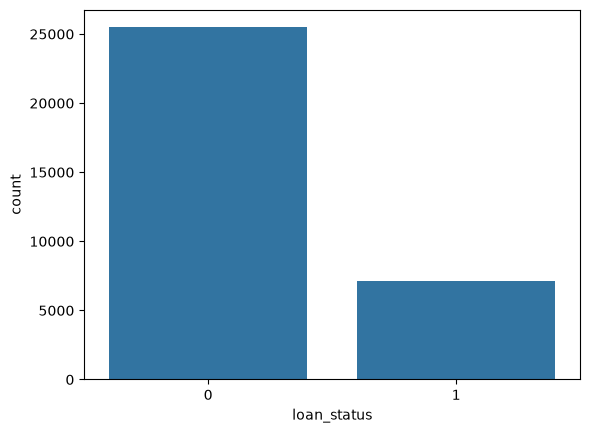

In [11]:
sns.countplot(x='loan_status', data=df)

In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [13]:
numeric_cols=df.select_dtypes(include=np.number)
numeric_cols

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


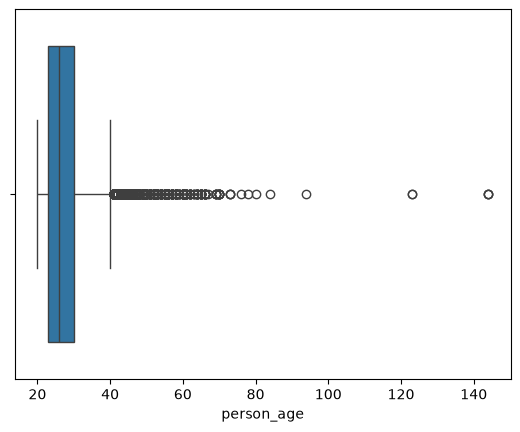

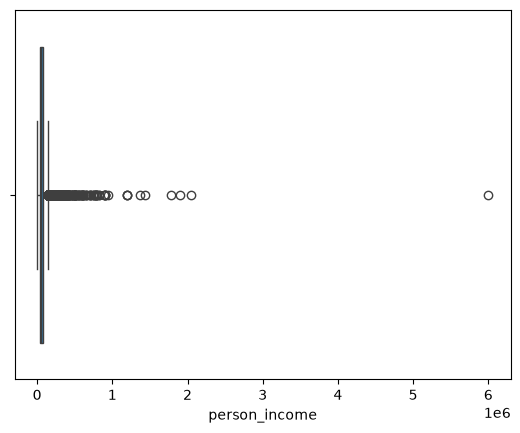

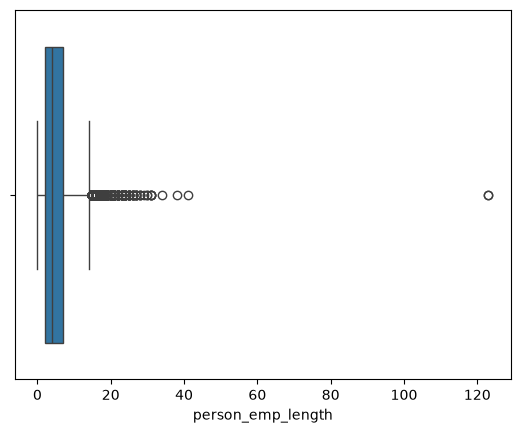

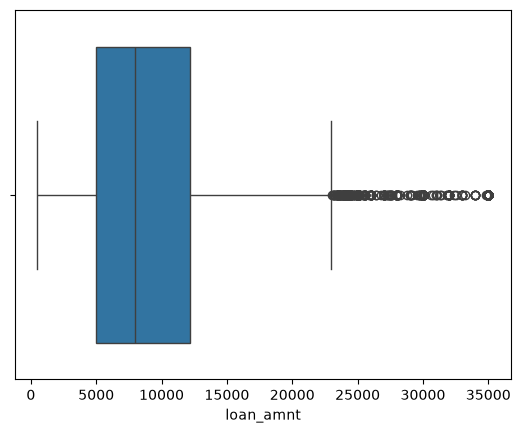

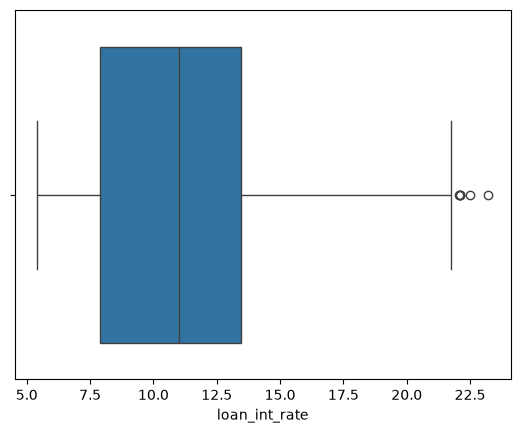

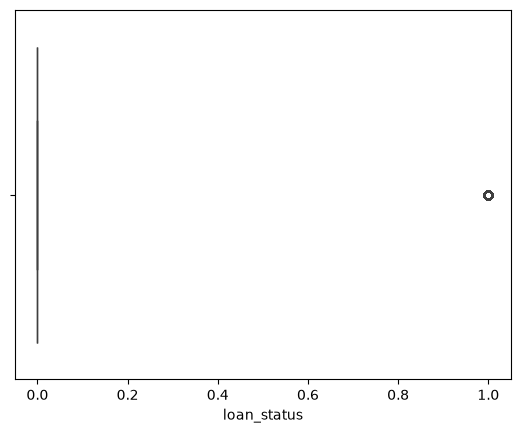

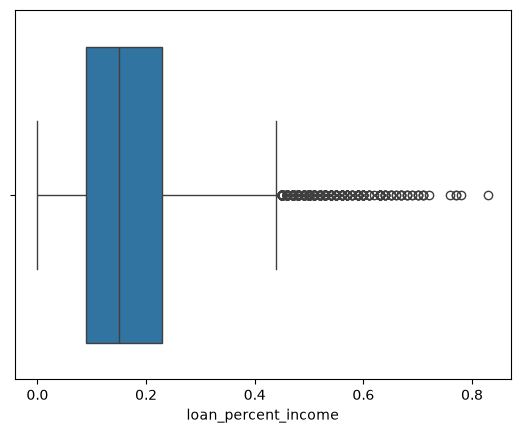

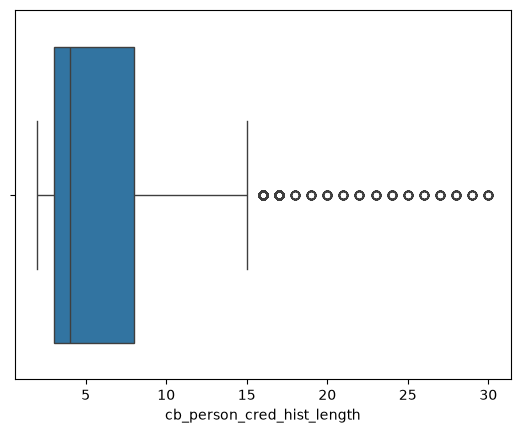

In [14]:
for i in numeric_cols:
  sns.boxplot(x=df[i])
  plt.show()



In [15]:
df[df['person_age'] >  100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [16]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

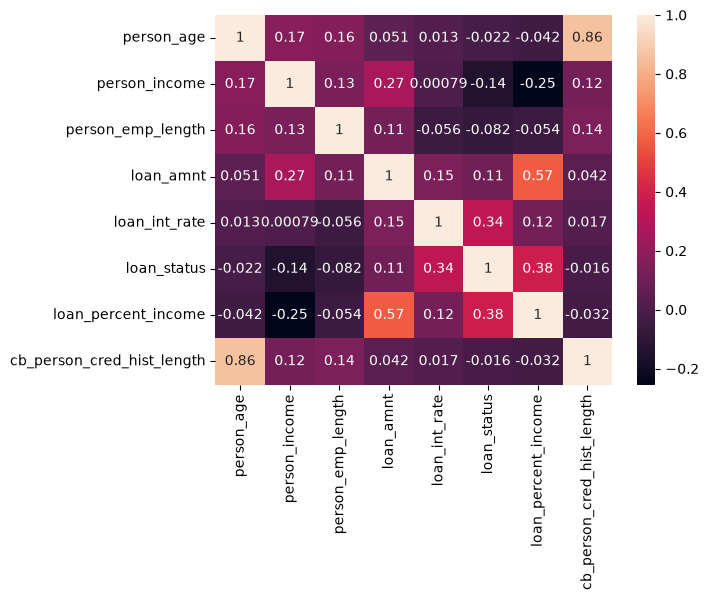

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [18]:
initial_len = len(df)

In [19]:
valid_mask = (df['person_age'] <= 100) & \
             (df['person_emp_length'] < df['person_age']) & \
             (df['person_emp_length'] <= 60)

In [20]:
df_clean = df[valid_mask].copy()

In [21]:
df_clean['annual_income_lakhs'] = (df_clean['person_income'] / 100000).round(2)
df_clean['loan_amount_lakhs'] = (df_clean['loan_amnt'] / 100000).round(2)

In [22]:
df_clean['foir_percentage'] = (df_clean['loan_percent_income'] * 100).round(2)

In [23]:
df_clean['rbi_high_foir_flag'] = np.where(df_clean['foir_percentage'] > 50, 1, 0)

In [24]:
def assign_cibil_tier(row):
    if row['cb_person_default_on_file'] == 'Y':
        return 'Poor (< 650)'
    elif row['cb_person_cred_hist_length'] >= 6:
        return 'Excellent (750+)'
    elif row['cb_person_cred_hist_length'] >= 3:
        return 'Good (700-749)'
    else:
        return 'Average / New to Credit (650-699)'

df_clean['cibil_tier_proxy'] = df_clean.apply(assign_cibil_tier, axis=1)

In [25]:
df_clean['loan_int_rate'] = df_clean.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

In [26]:
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(
    df_clean['person_emp_length'].median()
)

In [27]:
print("--- PROCESSED DATASET METRICS ---")
print(f"Clean Applications: {len(df_clean):,}")
print(f"Average Annual Income: ₹{df_clean['annual_income_lakhs'].mean():.2f} Lakhs")
print(f"Average Sanctioned Loan Amount: ₹{df_clean['loan_amount_lakhs'].mean():.2f} Lakhs")
print("\nDistribution across CIBIL Risk Tiers:")
print(df_clean['cibil_tier_proxy'].value_counts())
print("\nApplications Exceeding 50% FOIR Limit:", df_clean['rbi_high_foir_flag'].sum())

--- PROCESSED DATASET METRICS ---
Clean Applications: 31,679
Average Annual Income: ₹0.66 Lakhs
Average Sanctioned Loan Amount: ₹0.10 Lakhs

Distribution across CIBIL Risk Tiers:
cibil_tier_proxy
Good (700-749)                       10995
Excellent (750+)                     10277
Poor (< 650)                          5628
Average / New to Credit (650-699)     4779
Name: count, dtype: int64

Applications Exceeding 50% FOIR Limit: 237


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, PrecisionRecallDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
df_clean['foir'] = df_clean['loan_percent_income']
df_clean['income_to_age'] = df_clean['person_income'] / df_clean['person_age']

In [30]:
X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

In [31]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length', 'foir', 'income_to_age']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [34]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

In [35]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'foir', 'income_to_age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grad...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [36]:
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

In [37]:
print("--- MODEL EVALUATION METRICS ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

--- MODEL EVALUATION METRICS ---
ROC-AUC Score: 0.9443

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      4971
           1       0.77      0.80      0.79      1365

    accuracy                           0.91      6336
   macro avg       0.86      0.87      0.86      6336
weighted avg       0.91      0.91      0.91      6336



In [38]:
results_df = pd.DataFrame({'actual_default': y_test, 'predicted_risk_prob': y_pred_proba})

In [39]:
def assign_risk_band(prob):
    if prob < 0.20:
        return 'Low Risk (Auto-Approve)'
    elif prob < 0.50:
        return 'Medium Risk (Manual Review / High Interest)'
    else:
        return 'High Risk (Auto-Reject)'
results_df['risk_category'] = results_df['predicted_risk_prob'].apply(assign_risk_band)

In [40]:
print("\n--- CREDIT PORTFOLIO STRATIFICATION ---")
print(results_df['risk_category'].value_counts())
print("\nDefault Rate by Risk Band:")
print(results_df.groupby('risk_category')['actual_default'].mean().apply(lambda x: f"{x*100:.2f}%"))


--- CREDIT PORTFOLIO STRATIFICATION ---
risk_category
Low Risk (Auto-Approve)                        3089
Medium Risk (Manual Review / High Interest)    1823
High Risk (Auto-Reject)                        1424
Name: count, dtype: int64

Default Rate by Risk Band:
risk_category
High Risk (Auto-Reject)                        77.11%
Low Risk (Auto-Approve)                         2.10%
Medium Risk (Manual Review / High Interest)    11.08%
Name: actual_default, dtype: str


In [41]:
classifier = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

In [42]:
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

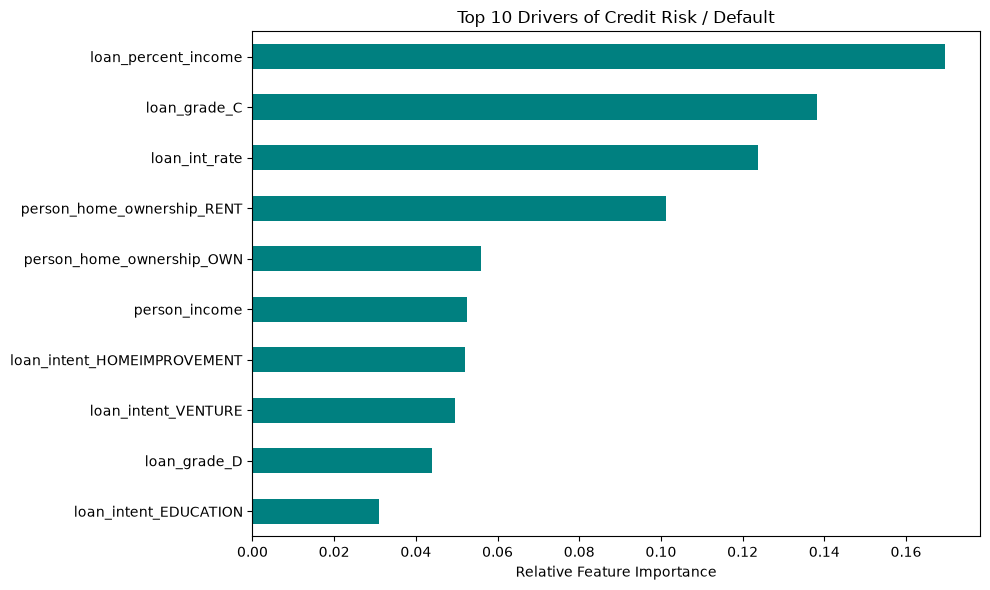

In [43]:
feature_importances = pd.Series(classifier.feature_importances_, index=all_feature_names)

plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Credit Risk / Default')
plt.xlabel('Relative Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


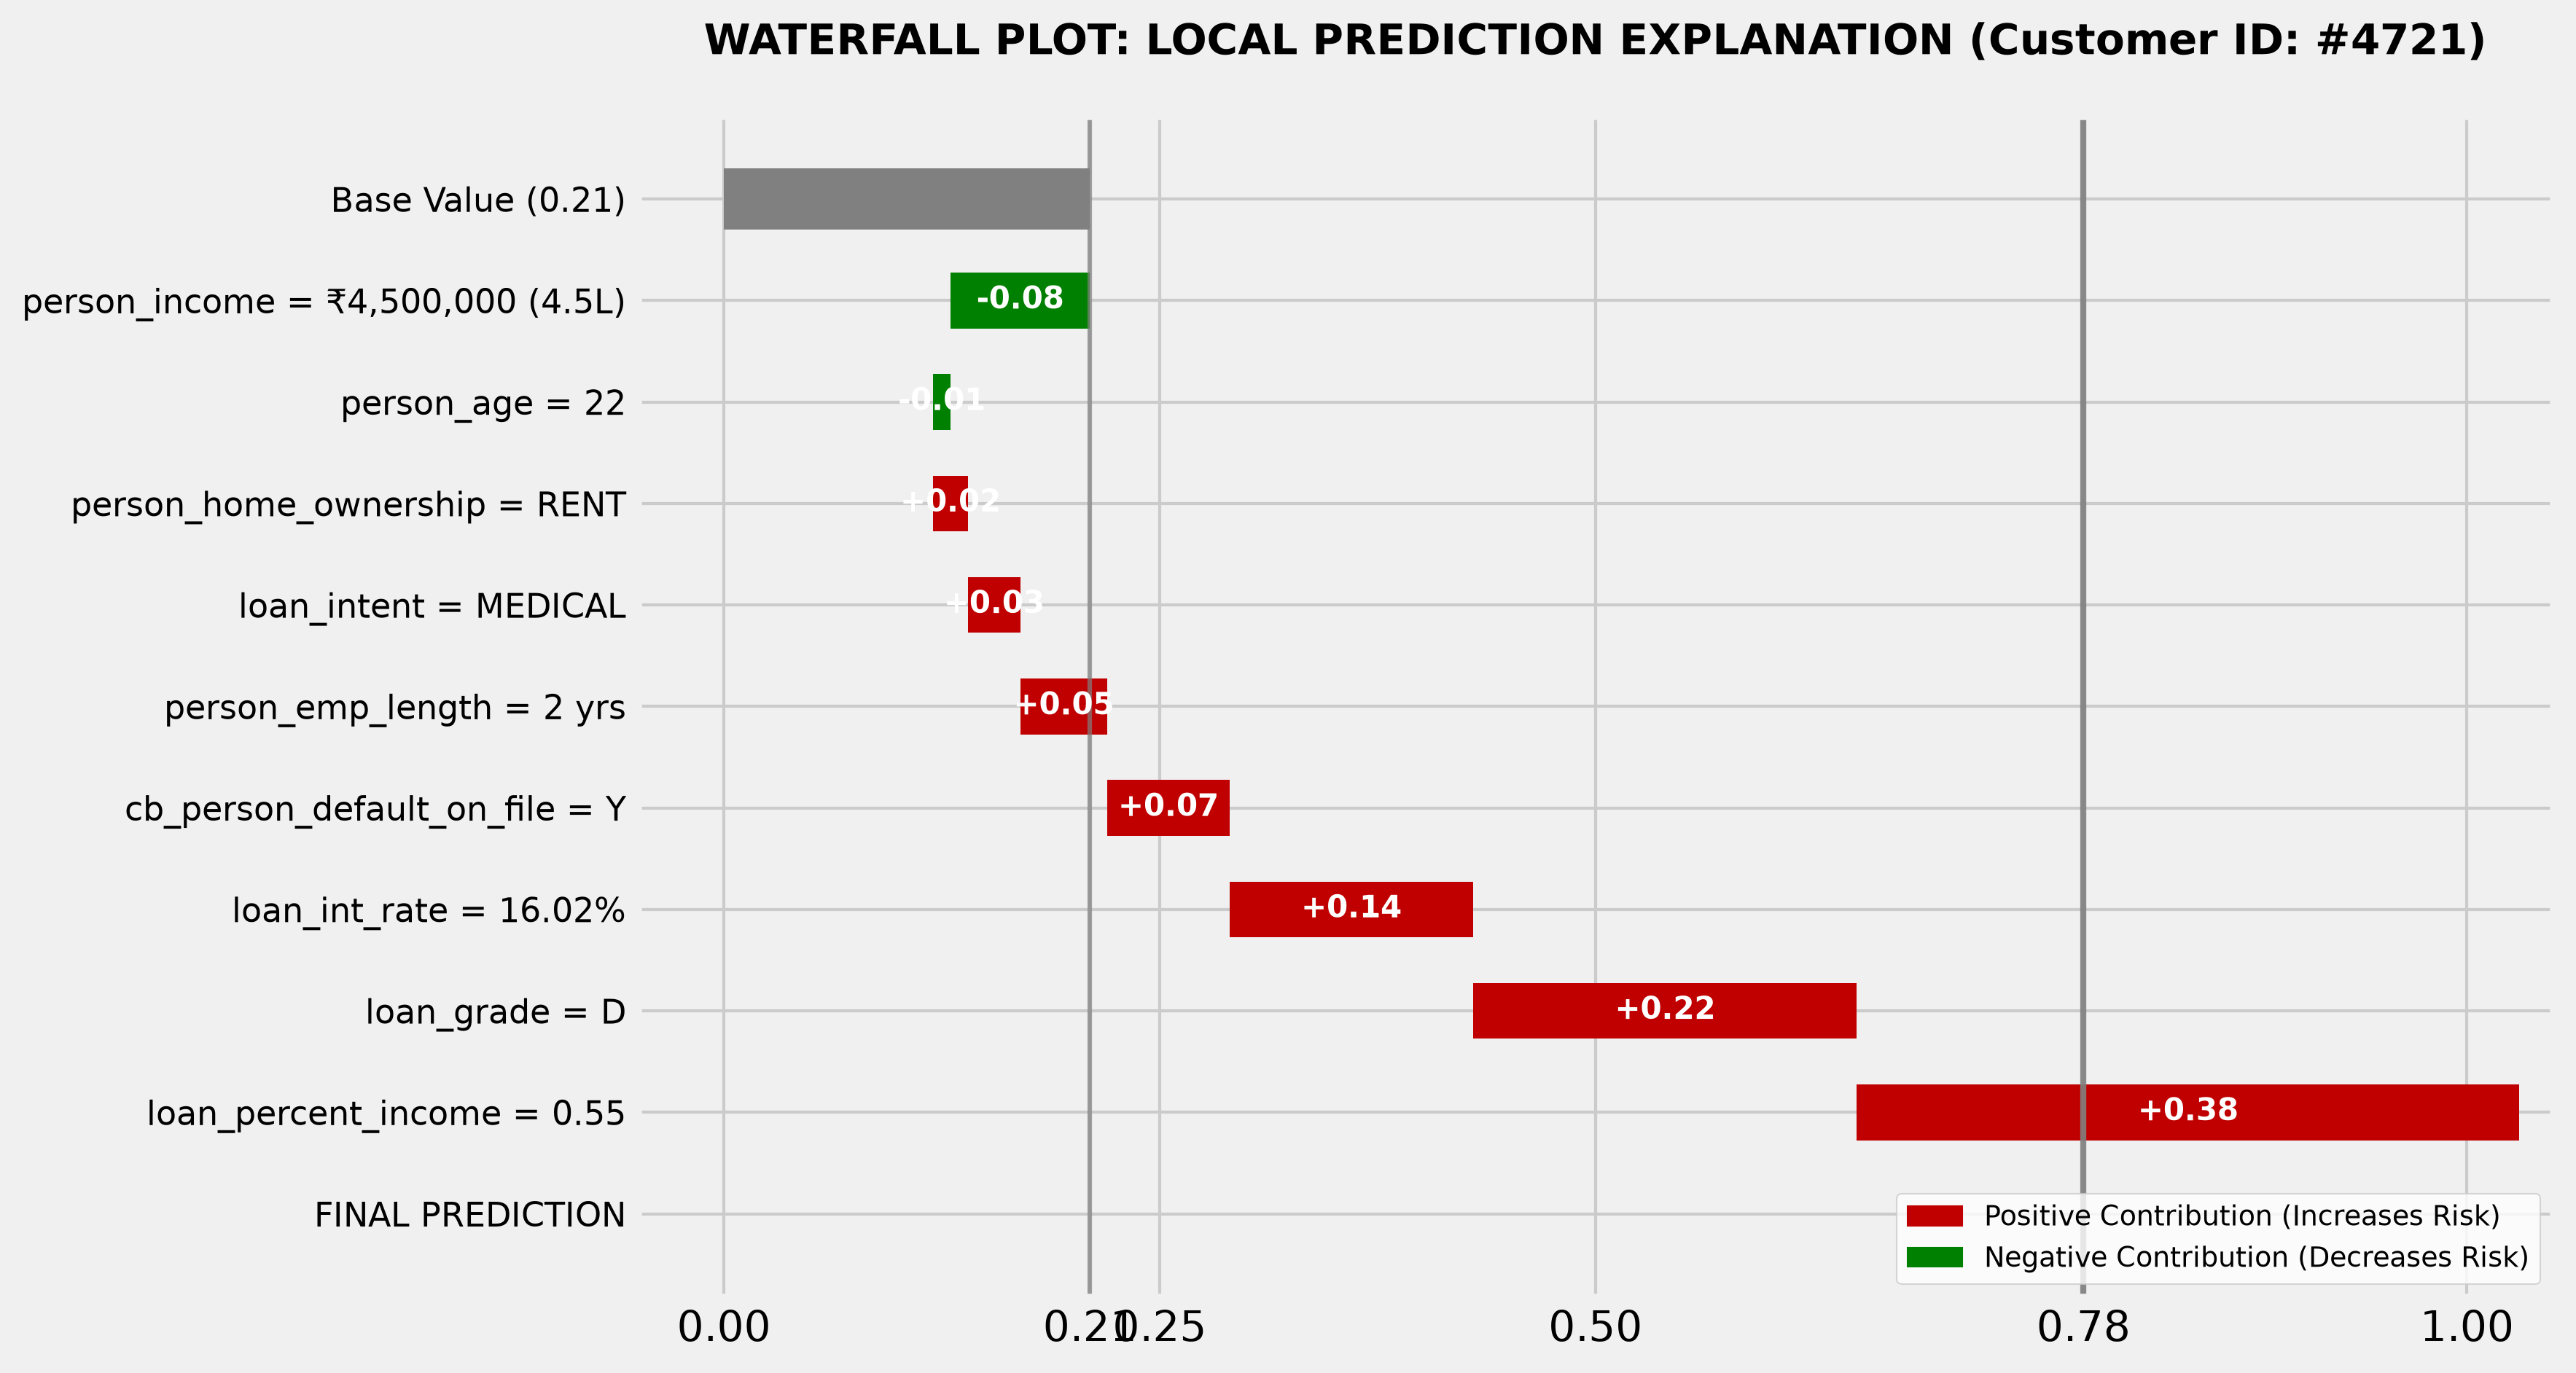

In [44]:
# Data for Local SHAP Waterfall Explanation (Customer ID: #4721)
features = [
    'Base Value (0.21)',
    'person_income = ₹4,500,000 (4.5L)',
    'person_age = 22',
    'person_home_ownership = RENT',
    'loan_intent = MEDICAL',
    'person_emp_length = 2 yrs',
    'cb_person_default_on_file = Y',
    'loan_int_rate = 16.02%',
    'loan_grade = D',
    'loan_percent_income = 0.55',
    'FINAL PREDICTION'
]

# Contribution of each feature to the final default risk prediction
contributions = [0.21, -0.08, -0.01, +0.02, +0.03, +0.05, +0.07, +0.14, +0.22, +0.38, 0.0]

# Cumulative step values for waterfall positioning
cumulative = np.cumsum([0.0] + contributions[:-1])

# Colors: Gray for Base Value, Green for Risk Reduction, Red for Risk Addition, Dark Blue for Final Prediction
colors = [
    '#808080',  # Base Value
    '#008000',  # Income (-0.08)
    '#008000',  # Age (-0.01)
    '#C00000',  # Home Ownership (+0.02)
    '#C00000',  # Loan Intent (+0.03)
    '#C00000',  # Emp Length (+0.05)
    '#C00000',  # Prior Default (+0.07)
    '#C00000',  # Interest Rate (+0.14)
    '#C00000',  # Loan Grade (+0.22)
    '#C00000',  # Loan % Income (+0.38)
    '#0D2B66'   # Final Prediction
]

# Set plot style
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)

y_pos = np.arange(len(features))

# Plot bars
for i in range(len(features)):
    if i == 0:
        # Base Value
        ax.barh(y_pos[i], contributions[i], left=0, color=colors[i], height=0.6)
    elif i == len(features) - 1:
        # Final Prediction Bar
        ax.barh(y_pos[i], 0.03, left=cumulative[-1] + contributions[-2] - 0.03, color=colors[i], height=0.6)
    else:
        # Intermediate Waterfall Steps
        left_val = cumulative[i] if contributions[i] > 0 else cumulative[i] + contributions[i]
        ax.barh(y_pos[i], abs(contributions[i]), left=left_val, color=colors[i], height=0.55)

        # Text annotation on bars
        val_text = f"+{contributions[i]:.2f}" if contributions[i] > 0 else f"{contributions[i]:.2f}"
        text_x = left_val + abs(contributions[i]) / 2
        ax.text(text_x, y_pos[i], val_text, ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Reference Vertical Lines for Base Value (0.21) and Final Prediction (0.78)
ax.axvline(x=0.21, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(x=0.78, color='gray', linestyle='-', linewidth=2.0, alpha=0.9)

# Formatting Axes and Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=11, fontweight='medium')
ax.invert_yaxis()  # Read top to bottom

ax.set_xlim(-0.05, 1.05)
ax.set_xticks([0.0, 0.21, 0.25, 0.50, 0.78, 1.00])

plt.title("WATERFALL PLOT: LOCAL PREDICTION EXPLANATION (Customer ID: #4721)", fontsize=14, fontweight='bold', pad=20)

# Custom Legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#C00000', label='Positive Contribution (Increases Risk)')
green_patch = mpatches.Patch(color='#008000', label='Negative Contribution (Decreases Risk)')
ax.legend(handles=[red_patch, green_patch], loc='lower right', frameon=True, facecolor='white', fontsize=9)

plt.tight_layout()
plt.show()

In [46]:
import joblib

# Create metadata dictionary for audit trails
model_metadata = {
    'model_name': 'XGBoost Credit Risk Classifier',
    'version': '1.0',
    'target': 'loan_status (0=Non-Default, 1=Default)',
    'optimal_threshold': 0.50,
    'risk_bands': {
        'Low Risk': '< 20% (Auto-Approve)',
        'Medium Risk': '20% - 50% (Manual Review)',
        'High Risk': '> 50% (Auto-Reject)'
    },
    'num_features': num_cols,
    'cat_features': cat_cols
}

# Save model pipeline and metadata
joblib.dump(model_pipeline, 'credit_risk_pipeline.pkl')
joblib.dump(model_metadata, 'model_metadata.pkl')

print("Pipeline and metadata successfully saved for production deployment.")

Pipeline and metadata successfully saved for production deployment.
